<a href="https://colab.research.google.com/github/TetianaMar-888/Board-games-analysis/blob/main/notebooks/DM1_01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Understanding
### Board Games Dataset

This notebook covers:
1. Data semantics
2. Distribution of variables & statistics
3. Data quality assessment (missing values, sentinel values, inconsistencies)
4. Variable transformations
5. Correlation matrix & redundancy analysis

##Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

## 1. Data Semantics

Quick structural check before diving into individual variables.


In [ ]:
# Loading data
data = pd.read_csv('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/data/DM1_game_dataset.csv')
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21924 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            16395 non-null  float64
 9   LanguageEase         16034 non-null  float64
 10  BestPlayers          21925 non-null  int64  
 11  GoodPlayers          21925 non-null  object 
 12  NumOwned             21925 non-null  int64  
 13  NumWant              21925 non-null  int64  
 14  NumWish              21925 non-null  int64  
 15  NumWeightVotes       21925 non-null 

## Key variables used in this analysis:


- **Rating** (target): community rating category — Low / Medium / High
- **GameWeight / ComWeight**: game complexity (1–5 scale), manufacturer- vs.
  community-assessed. The two are perfectly correlated (r = 1.00); only
  `ComWeight` is retained
- **MinPlayers / MaxPlayers / BestPlayers**: player count range, plus the
  community-voted optimal count. `BestPlayers` uses 0 as a "no verdict yet"
  sentinel for 91% of games and is replaced by the binary `BestPlayers_known`
- **YearPublished**: release year
- **NumOwned / NumWant / NumWish**: popularity/demand signals (owned, wanted,
  wishlisted by users)
- **MfgPlaytime / ComMinPlaytime / ComMaxPlaytime**: playtime in minutes,
  manufacturer vs. community estimate
- **NumUserRatings / NumComments / NumWeightVotes**: engagement signals.
  `NumComments` is constant at 0 for every record — an empty column — and is
  dropped
- **Rank:* columns**: rank within specific game categories (21926 = sentinel
  value meaning "not ranked in this category", not a literal rank)
- **Cat:* columns**: binary flags for game category membership (Thematic,
  Strategy, War, Family, CGS, Abstract, Party, Childrens)

## 2. Distribution of variables & statistics

         GameWeight     ComWeight    MinPlayers    MaxPlayers     ComAgeRec  \
count  21925.000000  21925.000000  21925.000000  21925.000000  16395.000000   
mean       1.982131      2.177479      2.007343      5.707868     10.004391   
std        0.848983      0.861781      0.693093     15.014643      3.269157   
min        0.000000      0.000000      0.000000      0.000000      2.000000   
25%        1.333300      1.513400      2.000000      4.000000      8.000000   
50%        1.968800      2.128000      2.000000      4.000000     10.000000   
75%        2.525200      2.737700      2.000000      6.000000     12.000000   
max        5.000000      5.213200     10.000000    999.000000     21.000000   

       YearPublished       NumOwned       NumWant       NumWish  \
count   21925.000000   21925.000000  21925.000000  21925.000000   
mean     1985.494914    1467.848164     41.690946    228.457013   
std       212.486214    5294.120574    117.255229    788.477151   
min     -3500.000000

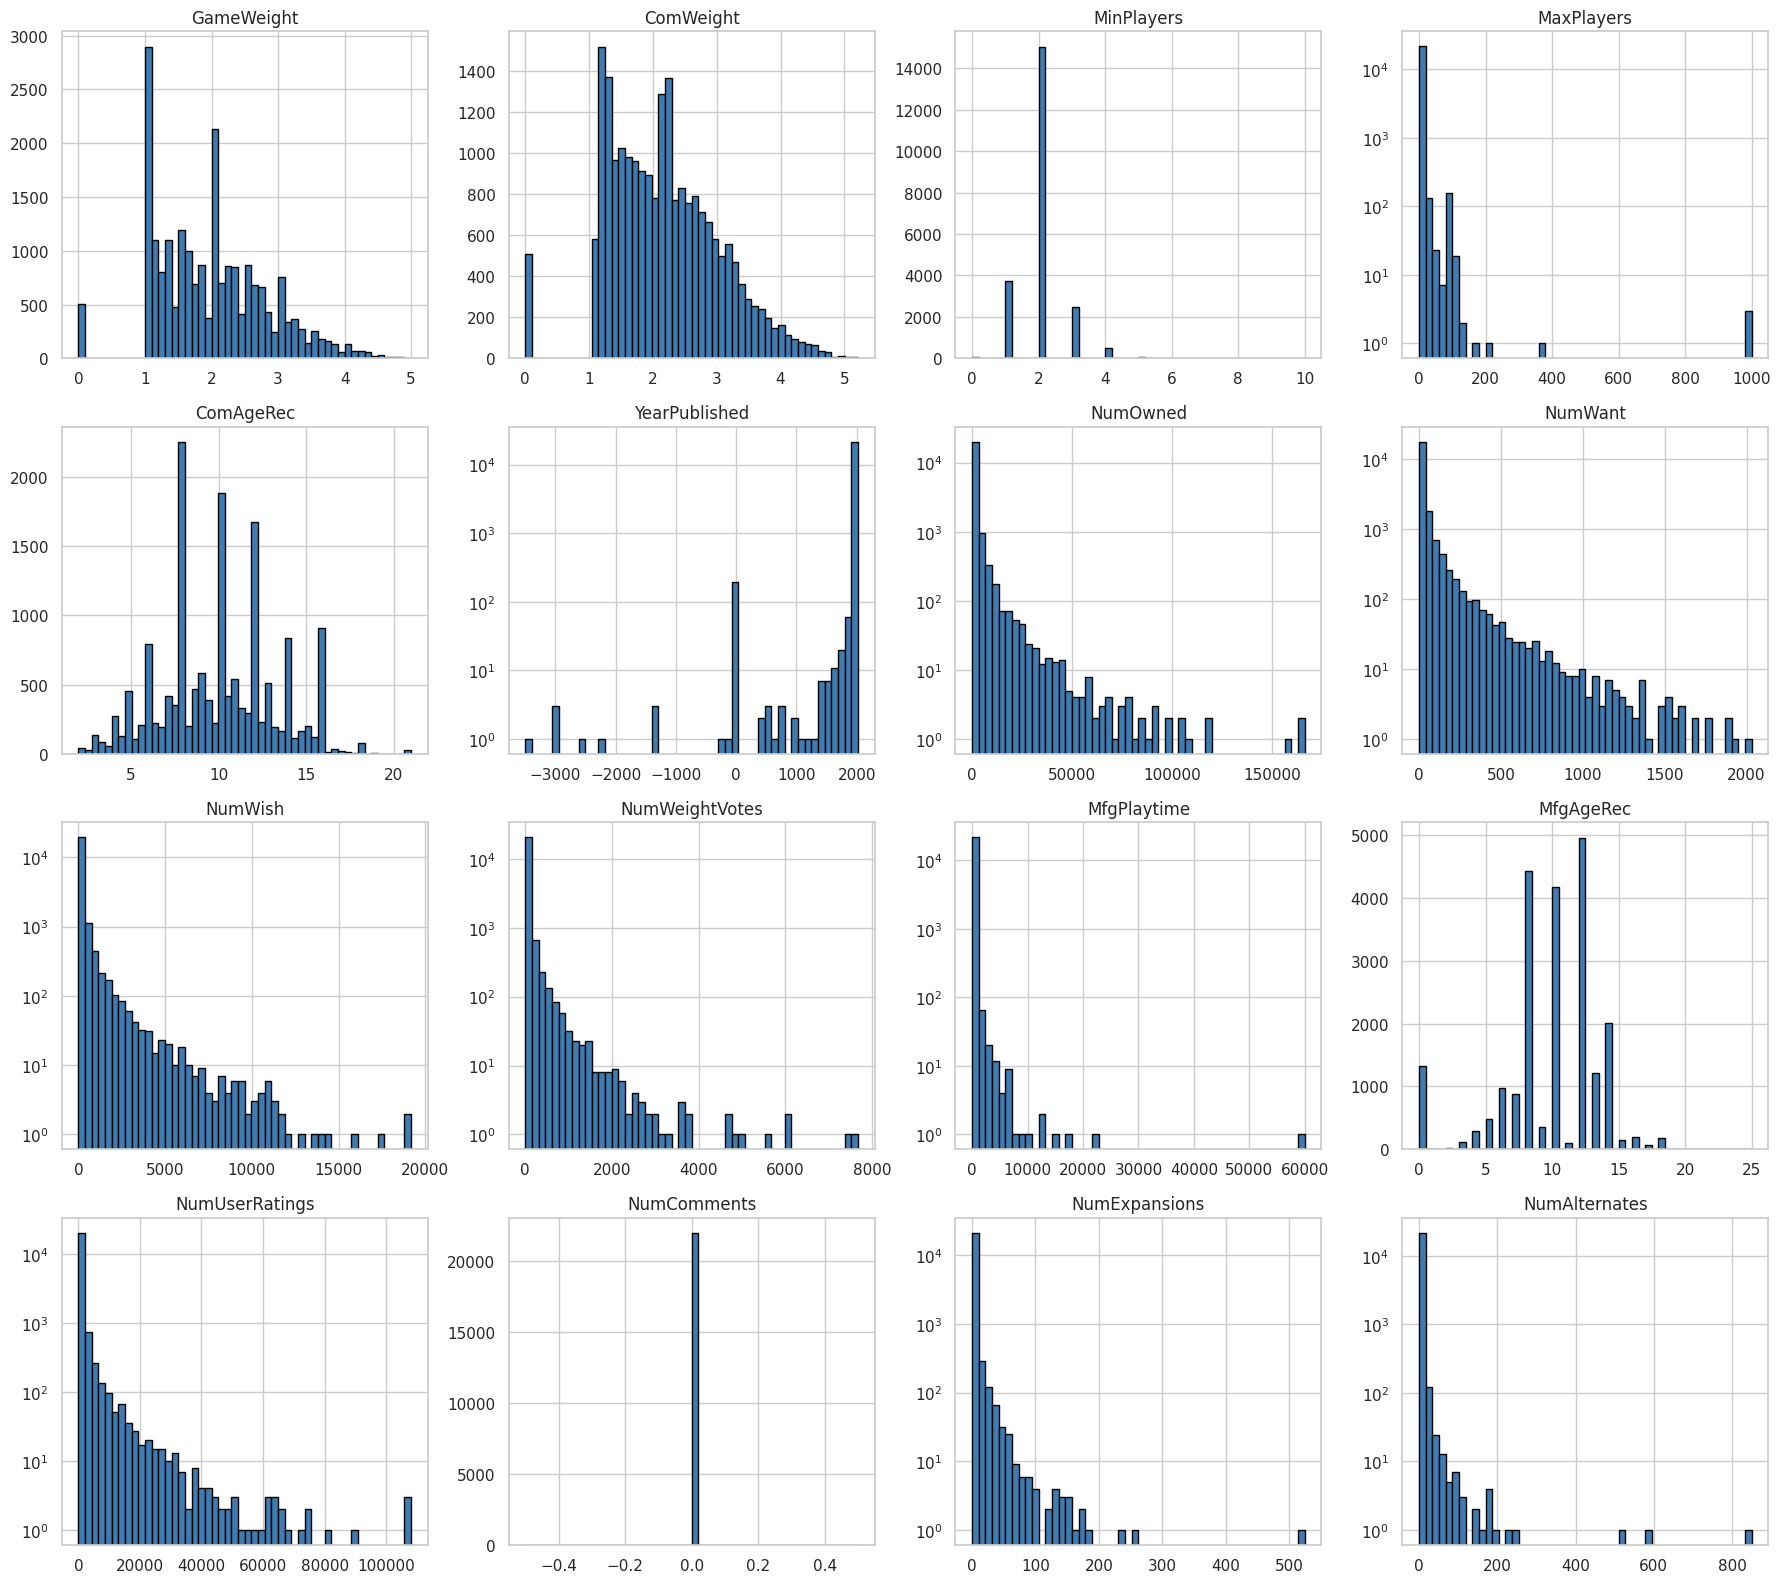

In [ ]:
numeric_cols = [
    "GameWeight", "ComWeight", "MinPlayers", "MaxPlayers", "ComAgeRec",
    "YearPublished", "NumOwned", "NumWant", "NumWish", "NumWeightVotes",
    "MfgPlaytime", "MfgAgeRec", "NumUserRatings", "NumComments",
    "NumExpansions", "NumAlternates"
]

print(data[numeric_cols].describe())

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col].dropna(), bins=50, color="#3E7CB1", edgecolor="black")
    axes[i].set_title(col)
    if data[col].max() > 100:  # strong skewed columns - log-scale
        axes[i].set_yscale("log")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/numeric_distributions.png', dpi=150)
plt.show()

The X-axis shows the range from -3000 to 2000! This means that some "games" have a publication year like -3000 (i.e. 3000 BC) — these are most likely ancient games like Go, Mangala, Senet (real historical games that were manually entered into the database with the historical date of invention). This is not a data error, but a feature of the dataset, but for ML models it creates a distortion but for ML models it creates a distortion. Combined with the 193 records where
YearPublished = 0 (unknown year rather than year zero), this motivates the
≥ 1900 filter applied in the data preparation step.

Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64
Rating
Medium    43.986317
Low       33.044470
High      22.969213
Name: proportion, dtype: float64


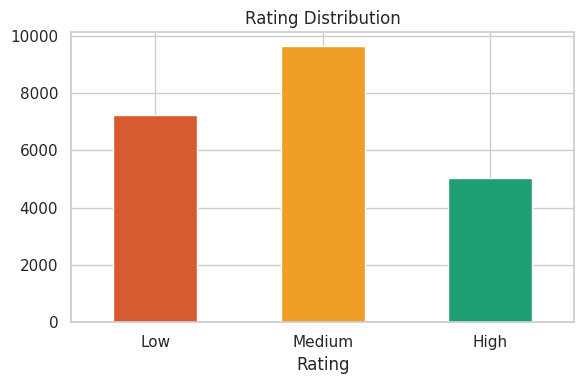

In [ ]:
print(data["Rating"].value_counts())
print(data["Rating"].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(6, 4))
data["Rating"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="bar", ax=ax, color=["#D85A30", "#EF9F27", "#1D9E75"])
ax.set_title("Rating Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/rating_distribution.png', dpi=150)
plt.show()

The distribution is moderately imbalanced (Medium 44%, Low 33%, High 23%). This
is mild enough that resampling techniques such as SMOTE are unnecessary; instead,
`class_weight='balanced'` is included among the hyperparameters tested during
grid search in Module 3, alongside the unweighted baseline. Macro-averaged F1 is
used as the model selection metric throughout, so that the minority High class
contributes equally to the score.

## 3. Data quality assessment (missing values, sentinel values, inconsistencies)

In [ ]:
rank_cols = [c for c in data.columns if c.startswith("Rank:")]

# How many games do NOT have a real rank in each category
for col in rank_cols:
    unranked_pct = (data[col] == 21926).mean() * 100
    print(f"{col}: {unranked_pct:.1f}% unranked (sentinel value)")

# Replace sentinel 21926 with NaN - this is not a real rank
for col in rank_cols:
    data[col] = data[col].replace(21926, np.nan)

# BestPlayers = 0 also sentinel
print("\nBestPlayers == 0:", (data["BestPlayers"] == 0).mean() * 100, "%")
data["BestPlayers_known"] = (data["BestPlayers"] != 0).astype(int)  # binary indicator

# Sentinel values disguised as valid numbers
sentinel_checks = {
    "ComWeight == 0":     data["ComWeight"] == 0,
    "MinPlayers == 0":    data["MinPlayers"] == 0,
    "MaxPlayers == 0":    data["MaxPlayers"] == 0,
    "MfgPlaytime == 0":   data["MfgPlaytime"] == 0,
    "MfgAgeRec == 0":     data["MfgAgeRec"] == 0,
    "YearPublished == 0": data["YearPublished"] == 0,
    "BestPlayers == 0":   data["BestPlayers"] == 0,
}
for name, mask in sentinel_checks.items():
    print(f"{name:22s} {mask.sum():6d}  ({mask.mean()*100:5.1f}%)")

# NumComments is constant
print("\nNumComments unique values:", data["NumComments"].unique())

# ComWeight == 0 -> is it really 'complexity zero', or 'nobody voted'?
print("\nComWeight == 0, their NumWeightVotes:")
print(data.loc[data["ComWeight"] == 0, "NumWeightVotes"].describe())

# ComWeight is documented as a 1-5 scale, but:
print("\nComWeight range:", data["ComWeight"].min(), "-", data["ComWeight"].max())

Rank:strategygames: 89.4% unranked (sentinel value)
Rank:abstracts: 94.9% unranked (sentinel value)
Rank:familygames: 89.4% unranked (sentinel value)
Rank:thematic: 94.4% unranked (sentinel value)
Rank:cgs: 98.6% unranked (sentinel value)
Rank:wargames: 83.9% unranked (sentinel value)
Rank:partygames: 97.1% unranked (sentinel value)
Rank:childrensgames: 96.0% unranked (sentinel value)

BestPlayers == 0: 90.96465222348917 %
ComWeight == 0            506  (  2.3%)
MinPlayers == 0            50  (  0.2%)
MaxPlayers == 0           173  (  0.8%)
MfgPlaytime == 0          780  (  3.6%)
MfgAgeRec == 0           1325  (  6.0%)
YearPublished == 0        193  (  0.9%)
BestPlayers == 0        19944  ( 91.0%)

NumComments unique values: [0]

ComWeight == 0, their NumWeightVotes:
count    506.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: NumWeightVotes, dtype: float64

ComWeight range: 0.0 - 5.2132


In [ ]:
# Semantic consistency: relationships between columns that must logically hold
checks = {
    "MinPlayers > MaxPlayers":         data["MinPlayers"] > data["MaxPlayers"],
    "ComMinPlaytime > ComMaxPlaytime": data["ComMinPlaytime"] > data["ComMaxPlaytime"],
    "MinPlayers == 0 & MaxPlayers > 0": (data["MinPlayers"] == 0) & (data["MaxPlayers"] > 0),
    "ComWeight > 5 (nominal scale max)": data["ComWeight"] > 5,
    "NumWeightVotes > NumUserRatings": data["NumWeightVotes"] > data["NumUserRatings"],
}
for name, mask in checks.items():
    print(f"{name:36s} {mask.sum():5d}")

# Overlap between the sentinel masks — so the total row loss is not double counted
players_bad = (data["MinPlayers"] == 0) | (data["MaxPlayers"] == 0) | (data["MinPlayers"] > data["MaxPlayers"])
year_bad    = data["YearPublished"] < 1900
maxp_bad    = data["MaxPlayers"] > 20
print(f"\nRows removed by any row-level filter: {(players_bad | year_bad | maxp_bad).sum()}")

MinPlayers > MaxPlayers                132
ComMinPlaytime > ComMaxPlaytime        151
MinPlayers == 0 & MaxPlayers > 0         9
ComWeight > 5 (nominal scale max)       13
NumWeightVotes > NumUserRatings          1

Rows removed by any row-level filter: 744


### Sentinel values disguised as valid numbers

Beyond the explicit `Rank:*` sentinel (21926), five further columns encode
"not specified" as a zero that is indistinguishable from a legitimate value by
type alone. Each was verified before treatment:

| Column | Zeros | Share | Interpretation | Treatment |
|---|---|---|---|---|
| `NumComments` | 21,925 | 100% | column is constant — carries no information | dropped |
| `BestPlayers` | 19,944 | 91.0% | community never reached a verdict | replaced by binary `BestPlayers_known` |
| `MfgAgeRec` | 1,325 | 6.0% | age not stated by the manufacturer | → NaN |
| `MfgPlaytime` | 780 | 3.6% | playtime not stated by the manufacturer | → NaN (+ `MfgPlaytime_missing` flag) |
| `ComWeight` | 506 | 2.3% | nobody voted on complexity | → NaN (+ `ComWeight_missing` flag) |
| `YearPublished` | 193 | 0.9% | year unknown | removed by the ≥1900 filter |
| `MaxPlayers` | 173 | 0.8% | player count not specified | rows removed |
| `MinPlayers` | 50 | 0.2% | player count not specified | rows removed |

The `ComWeight` case is the clearest: all 506 games with `ComWeight = 0` have
`NumWeightVotes = 0` (mean, standard deviation and maximum are all exactly zero).
The value therefore records the absence of community votes, not a game of zero
complexity. Leaving it untreated would be particularly damaging, since
`ComWeight` serves as the target variable of the regression task in Module 3:
506 artificial zeros at the lower bound of the scale would bias the fitted
relationship and inflate the apparent explained variance.

A secondary observation: `ComWeight` is documented as a 1–5 complexity scale but
its observed maximum is 5.2132. The community score is an average of individual
votes on a slightly wider internal scale; the excess is marginal and no
truncation was applied.

In [ ]:
# Are the 132 "inversions" just the MaxPlayers == 0 sentinel?
inv = data["MinPlayers"] > data["MaxPlayers"]
print("MinPlayers > MaxPlayers:              ", inv.sum())
print("  ...of which MaxPlayers == 0:        ", (inv & (data["MaxPlayers"] == 0)).sum())
print("  ...genuine inversions (both > 0):   ", (inv & (data["MaxPlayers"] > 0)).sum())

# ComMinPlaytime > ComMaxPlaytime — sentinel, or transposed entry?
bad = data["ComMinPlaytime"] > data["ComMaxPlaytime"]
print("\nComMinPlaytime > ComMaxPlaytime:     ", bad.sum())
print("  ...of which ComMaxPlaytime == 0:    ", (bad & (data["ComMaxPlaytime"] == 0)).sum())
print("  ...both values > 0 (transposed?):   ", (bad & (data["ComMaxPlaytime"] > 0)).sum())
print()
print(data.loc[bad, ["Name", "ComMinPlaytime", "ComMaxPlaytime", "MfgPlaytime"]].head(10))

MinPlayers > MaxPlayers:               132
  ...of which MaxPlayers == 0:         132
  ...genuine inversions (both > 0):    0

ComMinPlaytime > ComMaxPlaytime:      151
  ...of which ComMaxPlaytime == 0:     147
  ...both values > 0 (transposed?):    4

                                                   Name  ComMinPlaytime  \
100                          Miskatonic School for Boys              45   
168                             Polyhedral Park Planner              30   
176                                      Artifact Stack              20   
793                                           Würfel-WG              35   
1068                                        Monster Kit              10   
1154                                              Totem              30   
1192                                        Gold Armada              20   
1340                         Superfight: The Anime Deck              30   
1558                                           Okavango              4

### Semantic inconsistencies

Beyond univariate sentinel detection, cross-column logical constraints were
checked. Four violations were found, of which only one is substantive:

| Constraint violated | Records | Verdict |
|---|---|---|
| `MinPlayers > MaxPlayers` | 132 | not a genuine inversion — see below |
| `ComMinPlaytime > ComMaxPlaytime` | 151 | genuine inconsistency |
| `ComWeight > 5` (nominal scale maximum) | 13 | negligible, tolerated |
| `NumWeightVotes > NumUserRatings` | 1 | single record, tolerated |

The 132 apparent player-count inversions dissolve on inspection: all of them are
records where `MaxPlayers = 0`, i.e. the sentinel identified in the previous
section, paired with a non-zero `MinPlayers`. The arithmetic is exact — of the 50
records with `MinPlayers = 0`, 9 have `MaxPlayers > 0`, leaving 41 with both
fields zero; subtracting these from the 173 records with `MaxPlayers = 0` yields
precisely 132. The dataset therefore contains no genuinely transposed player
counts, and no swap rule is required: removing the sentinel rows resolves the
constraint violation as a side effect.

`ComWeight` exceeding its nominal maximum of 5 (13 records, observed maximum
5.2132) reflects the fact that the community score is an average over a slightly
wider internal voting scale. The excess is marginal and no truncation was applied,
since clipping would introduce an artificial spike at the boundary.

### Outlier Detection & Handling

In [ ]:
# YearPublished: historical games with negative/very old years distort the distribution
print("Games with YearPublished < 1900:", (data["YearPublished"] < 1900).sum())
print(data[data["YearPublished"] < 1900][["Name", "YearPublished"]].head(10))

# MaxPlayers: unrealistic values (e.g. 999) likely encode "unlimited" or data entry errors
print("\nGames with MaxPlayers > 20:", (data["MaxPlayers"] > 20).sum())
print(data[data["MaxPlayers"] > 20][["Name", "MinPlayers", "MaxPlayers"]].head(10))

# MfgPlaytime: extreme values (e.g. 60000 minutes = 1000 hours) are not realistic for board games
print("\nGames with MfgPlaytime > 1000:", (data["MfgPlaytime"] > 1000).sum())
print(data[data["MfgPlaytime"] > 1000][["Name", "MfgPlaytime"]].head(10))

Games with YearPublished < 1900: 309
                    Name  YearPublished
47                  Skat           1810
61                 Durak              0
181              Le Truc              0
392   Eurooppa Tietopeli              0
610     Hungarian Tarokk           1870
751                 1000              0
806   Chutes and Ladders           -200
821                Geni!              0
880            Alquerque           1000
1010             Manille              0

Games with MaxPlayers > 20: 278
                                                 Name  MinPlayers  MaxPlayers
110   The Hammer of Thor: The Game of Norse Mythology           1         362
168                           Polyhedral Park Planner           1         100
293                                          Diáspora           1          24
498          Warhammer Fantasy Battle (Third Edition)           2          99
510                                     Rolling Japan           1          99
577                   

Four variables show extreme or sentinel values that require different treatment:

* **YearPublished**: a sentinel value of 0 (unknown year) and a handful of
  genuinely ancient games (entered with historical invention dates such as -3500)
  distort the distribution. Filtered to YearPublished ≥ 1900 — a pragmatic cutoff
  that also removes a small number of legitimate 19th-century games (e.g. Skat,
  1810), an acceptable trade-off for data consistency.
* **MaxPlayers**: values like 99, 362, or 999 almost certainly encode "unlimited"
  or reflect data entry errors, since no realistic board game supports hundreds
  of players. These 278 records are removed rather than capped: replacing 999
  with 20 would fabricate a plausible-looking value the data does not support,
  and at this volume the cost in sample size is negligible.
* **MfgPlaytime**: unlike the other two, extreme values here (e.g. 8,640–17,280
  minutes) correspond to genuine "monster wargames" known for multi-day campaign
  play — not errors. Rather than removing these records, MfgPlaytime was
  log-transformed to reduce their disproportionate influence on distance-based
  methods (clustering, regression) while preserving the signal. The transform is
  applied only after the 780 zero-coded records have been converted to NaN, since
  log1p would otherwise map "not specified" onto a legitimate-looking value of 0.
* **ComWeight**: not an outlier problem but its mirror image — 506 games carry a
  value of 0 encoding "nobody voted" rather than zero complexity, confirmed by
  the fact that all 506 have `NumWeightVotes = 0` (mean, standard deviation and
  maximum all exactly zero). Converted to NaN. This matters more than the record
  count suggests, since `ComWeight` is the target variable of the regression task
  in Module 3, where 506 artificial zeros at the bottom of the scale would bias
  the fitted relationship.

The distinction between the two strategies is deliberate. Records are removed
where the value is unrecoverable and the affected volume is small (YearPublished,
MaxPlayers); values are converted to NaN where the column is needed downstream
and the missingness is itself informative (MfgPlaytime, ComWeight). In the latter
case binary indicators (`MfgPlaytime_missing`, `ComWeight_missing`) preserve the
fact that the value was absent, so that a model can use it if it is predictive.

### 4. GoodPlayers parsing

In [ ]:
import ast

def parse_good_players(val):
    if pd.isna(val):
        return 0
    try:
        parsed = ast.literal_eval(str(val))
    except (ValueError, SyntaxError):
        return 0
    if isinstance(parsed, (list, tuple, set)):
        return len(parsed)
    if isinstance(parsed, (int, float)):
        return 1
    return 0

data["GoodPlayers_count"] = data["GoodPlayers"].apply(parse_good_players)

print("Raw examples:", data["GoodPlayers"].head(5).tolist())
print()
print(data["GoodPlayers_count"].describe())

# Is GoodPlayers non-empty exactly where the community reached a verdict?
print("Empty '[]':", (data["GoodPlayers"] == "[]").sum(),
      f"({(data['GoodPlayers'] == '[]').mean()*100:.1f}%)")
print(pd.crosstab(data["GoodPlayers_count"] > 0, data["BestPlayers"] != 0,
                  rownames=["GoodPlayers non-empty"], colnames=["BestPlayers known"]))

Raw examples: ['[]', '[]', '[]', '[]', '[]']

count    21925.00000
mean         0.26764
std          0.92418
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max         21.00000
Name: GoodPlayers_count, dtype: float64
Empty '[]': 19946 (91.0%)
BestPlayers known      False  True 
GoodPlayers non-empty              
False                  19944      2
True                       0   1979


### GoodPlayers

`GoodPlayers` stores, for each game, the list of player counts the community
voted as "good". The field is empty (`[]`) for 19,946 games (91.0%), leaving a
mean of only 0.27 recommended player counts per record.

Cross-tabulating it against `BestPlayers` shows the two fields are governed by
the same mechanism: of 21,925 records, 1,979 have both a non-empty `GoodPlayers`
list and a non-zero `BestPlayers`, 19,944 have neither, and only 2 records
disagree. Both columns are published by BGG only once a game has accumulated
enough community votes, so they encode the same underlying event — whether a
verdict on player count exists at all — rather than two independent signals.

Retaining both would introduce redundancy without adding information. `GoodPlayers`
and `BestPlayers` are therefore dropped, and the shared signal is preserved in a
single binary indicator, `BestPlayers_known`.

### Missing values ​​- the full picture

In [ ]:
missing = data.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(1)
print(pd.DataFrame({"missing": missing, "pct": missing_pct}).head(15))

                     missing   pct
Rank:cgs               21622  98.6
Rank:partygames        21285  97.1
Rank:childrensgames    21044  96.0
Rank:abstracts         20810  94.9
Rank:thematic          20701  94.4
Rank:familygames       19609  89.4
Rank:strategygames     19606  89.4
Rank:wargames          18395  83.9
Family                 15262  69.6
LanguageEase            5891  26.9
ComAgeRec               5530  25.2
ImagePath                 17   0.1
Description                1   0.0
ComWeight                  0   0.0
GameWeight                 0   0.0


### Missing values — decisions per column

The table above reports missingness after the `Rank:*` sentinel (21926) has been
converted to NaN. Each affected column was assigned an explicit treatment:

- **`Rank:*` (83.9–98.6% missing)** — dropped. The sentinel encodes "not ranked
  in this category". At this level of sparsity imputation is meaningless: any
  filled value would describe the imputation rule, not the games.
- **`Family` (69.6%)** — dropped. High-cardinality free text; encoding it would
  produce hundreds of near-empty dummy variables.
- **`LanguageEase` (26.9%)** — dropped. It is not required by any of the planned
  tasks, and retaining it would force an additional 27% row loss at every
  listwise-deletion step downstream.
- **`ComAgeRec` (25.2%)** — **retained**, despite comparable missingness. It is
  among the strongest predictors in the dataset (r = 0.65 with `ComWeight`) and
  is central to both the clustering and the regression task. The missingness is
  not random: it concentrates in older and less-reviewed games the community
  never voted on. Rows are dropped listwise in the modelling modules, and the
  resulting reduction in sample size is reported explicitly in Module 2.
- **`ImagePath` (0.1%)** and **`Description` (0.0%)** — dropped as non-analytical
  (URL and free text).

The contrast between `LanguageEase` and `ComAgeRec` is deliberate: at almost
identical missingness rates the two are treated in opposite ways, because the
decision rests on the predictive value of the column, not on the percentage alone.

Note that this table does not yet reflect the zero-coded sentinels identified in
the previous section (`ComWeight`, `MfgPlaytime`, `MfgAgeRec`, `MinPlayers`,
`MaxPlayers`). Those values are still stored as zeros at this point and are
converted to NaN in the data preparation step below, which is why the columns
appear here with 0.0% missing.

## 5. Correlation matrix

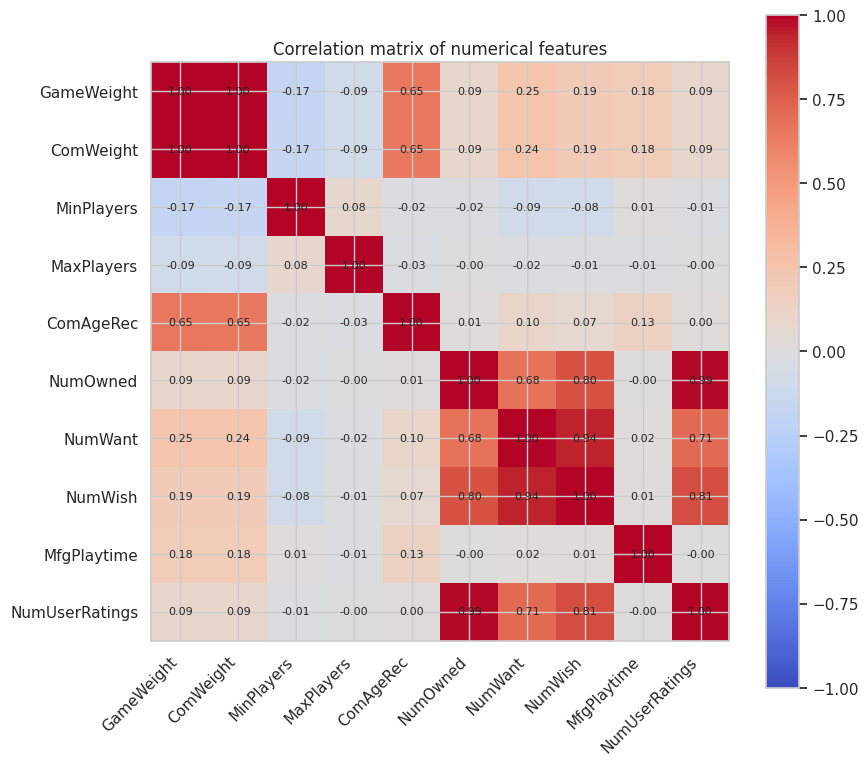

In [ ]:
corr_cols = [
    "GameWeight", "ComWeight", "MinPlayers", "MaxPlayers", "ComAgeRec",
    "NumOwned", "NumWant", "NumWish", "MfgPlaytime", "NumUserRatings"
]

corr = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
plt.title("Correlation matrix of numerical features")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/correlation_matrix.png', dpi=150)
plt.show()

Three patterns stand out in the matrix.

**`GameWeight` and `ComWeight` are the same variable** (r = 1.00). Both measure
complexity on a 1–5 scale, one as stated by the manufacturer and one as voted by
the community, and they agree perfectly. `GameWeight` is dropped and `ComWeight`
retained: the community score has a documented voting mechanism behind it
(`NumWeightVotes`), which is what made it possible to identify its zero sentinel.

**`ComAgeRec` correlates with complexity at r = 0.65** — more complex games carry
a higher recommended age. This is the strongest correlation in the dataset
between two conceptually independent variables, and it is substantively
meaningful rather than an artefact of shared construction. It is used in Module 3
as the independent variable of the simple regression task.

**The popularity indicators form a tightly coupled block**, but not a uniform one.
`NumOwned` and `NumUserRatings` correlate at r = 0.99 — a near-duplicate pair on
the same level as `GameWeight`/`ComWeight`, explained by the fact that BGG only
admits a game to the database once it passes a minimum rating count, so ownership
and rating volume grow together mechanically. The remaining pairs are lower:
`NumWish`/`NumUserRatings` at 0.81, `NumOwned`/`NumWish` at 0.80,
`NumWant`/`NumUserRatings` at 0.71 and `NumOwned`/`NumWant` at 0.68 — high, but
leaving room for each to carry some independent signal (a wishlisted game is not
the same as an owned one).

Two consequences follow for the modelling modules. First, `NumOwned` and
`NumUserRatings` should not both enter a model as predictors; one of them is
selected in Module 3. Second, no model should predict one member of this block
from the others, since the resulting fit would reflect shared origin rather than
explanatory power — which is why the regression task targets `ComWeight` instead
of a popularity variable.

Beyond these three patterns the matrix is largely flat: `MfgPlaytime` and
`MaxPlayers` correlate with almost nothing (|r| < 0.2 throughout), meaning they
contribute largely independent information and are worth retaining despite their
skewed distributions.

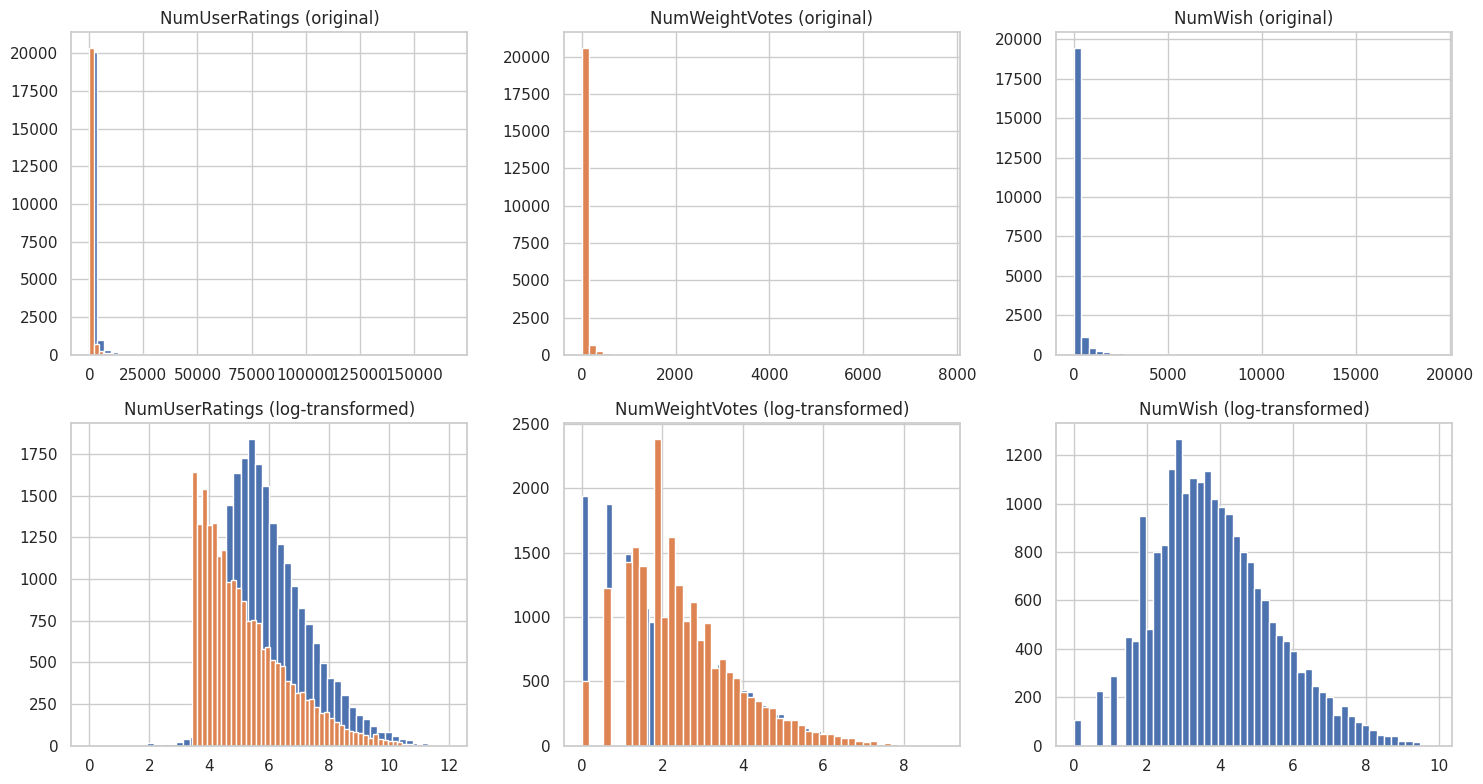

In [ ]:
#Log transformation for skewed variables
skewed_cols = ["NumOwned", "NumWant", "NumWish", "NumUserRatings", "NumWeightVotes"]

for col in skewed_cols:
    data[f"{col}_log"] = np.log1p(data[col])

# Before/after comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(skewed_cols):
    axes[0, i % 3].hist(data[col], bins=50)
    axes[0, i % 3].set_title(f"{col} (original)")
    axes[1, i % 3].hist(data[f"{col}_log"], bins=50)
    axes[1, i % 3].set_title(f"{col} (log-transformed)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/log_transform_comparison.png', dpi=150)
plt.show()

The graphs confirm: NumUserRatings and NumWeightVotes become much closer to normal distribution after log1p - it is worth using logarithmic versions for regression and clustering (where distance/linearity is important). NumComments - nothing meaningful there at all.

In [ ]:
data_clean = data.copy()
n_start = len(data_clean)

# 1. Row-level filters
# Applied first, on the raw zeros, so the removal count can be verified
# against the overlap figure computed in the data quality section (744).
data_clean = data_clean[data_clean["YearPublished"].between(1900, 2021)]
data_clean = data_clean[data_clean["MinPlayers"] > 0]
data_clean = data_clean[data_clean["MaxPlayers"].between(1, 20)]

n_removed = n_start - len(data_clean)
print(f"Rows: {n_start} -> {len(data_clean)}  ({n_removed} removed, {n_removed/n_start*100:.1f}%)")
assert n_removed == 744, f"Expected 744 rows removed, got {n_removed}"

# 2. Zero-coded sentinels -> NaN
# These zeros mean "not specified", not a measured value of zero.
for col in ["ComWeight", "MfgPlaytime", "MfgAgeRec", "ComMinPlaytime", "ComMaxPlaytime"]:
    data_clean[col] = data_clean[col].replace(0, np.nan)

#  3. Missingness indicators
# Preserve the information that a value was absent — it may itself be predictive.
data_clean["ComWeight_missing"]   = data_clean["ComWeight"].isna().astype(int)
data_clean["MfgPlaytime_missing"] = data_clean["MfgPlaytime"].isna().astype(int)
data_clean["BestPlayers_known"]   = (data_clean["BestPlayers"] != 0).astype(int)

#  4. Genuine playtime inversions
# 4 records have both playtime bounds > 0 but in the wrong order — transposed entry.
swap = data_clean["ComMinPlaytime"] > data_clean["ComMaxPlaytime"]
print(f"Transposed playtime pairs swapped: {swap.sum()}")
data_clean.loc[swap, ["ComMinPlaytime", "ComMaxPlaytime"]] = \
    data_clean.loc[swap, ["ComMaxPlaytime", "ComMinPlaytime"]].values

#  5. Column removal
data_clean = data_clean.drop(columns=[
    "NumComments",          # constant 0 across all rows — empty column
    "GameWeight",           # r = 1.00 with ComWeight — duplicate
    "Family",               # 69.6% missing, high-cardinality text
    "LanguageEase",         # 26.9% missing, unused downstream
    "BestPlayers",          # 91% sentinel; replaced by BestPlayers_known
    "GoodPlayers",          # same signal as BestPlayers (see cross-tabulation)
    "GoodPlayers_count",    # redundant with BestPlayers_known
    "ImagePath", "Description",
    *[c for c in data_clean.columns if c.startswith("Rank:")],
], errors="ignore")

#  6. Log transforms
for col in ["NumOwned", "NumWant", "NumWish", "NumUserRatings", "NumWeightVotes", "MfgPlaytime"]:
    data_clean[f"{col}_log"] = np.log1p(data_clean[col])

#  7. Save + report
data_clean.to_parquet('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/data/board_games_cleaned.parquet')

print("\nFinal shape:", data_clean.shape)
print("\nRemaining missing values:")
print(data_clean.isna().sum()[lambda s: s > 0].sort_values(ascending=False))

Rows: 21925 -> 21181  (744 removed, 3.4%)
Transposed playtime pairs swapped: 4

Final shape: (21181, 39)

Remaining missing values:
ComAgeRec          5277
MfgAgeRec          1210
MfgPlaytime         666
MfgPlaytime_log     666
ComMaxPlaytime      666
ComMinPlaytime      548
ComWeight           461
dtype: int64


### Result of data preparation

Row-level filtering removed 744 records (3.4%): games published before 1900 or
with an unknown year, and games whose player-count fields carried the zero
sentinel. The figure matches the overlap count computed in the data quality
section exactly, confirming that no record is removed twice by different rules
and that the filters capture what they were designed to capture. The resulting
dataset contains 21,181 games described by 39 variables.

Zero-coded sentinels were then converted to NaN, which is why several columns
now report missing values that were invisible in the earlier missingness table:

| Column | Missing | Share |
|---|---|---|
| `ComAgeRec` | 5,277 | 24.9% |
| `MfgAgeRec` | 1,210 | 5.7% |
| `MfgPlaytime` | 666 | 3.1% |
| `ComMaxPlaytime` | 666 | 3.1% |
| `ComMinPlaytime` | 548 | 2.6% |
| `ComWeight` | 461 | 2.2% |

`MfgPlaytime` and `ComMaxPlaytime` are missing for exactly the same 666 records,
indicating that a game either carries complete playtime information or none at
all — the fields are populated together rather than independently. `ComMinPlaytime`
is missing for 118 fewer records, i.e. a small group specifies a lower bound
without an upper one.

The trade-off is deliberate: converting these zeros to NaN makes the missingness
explicit and costs sample size in the modelling modules, but leaving them as
zeros would have placed 461 unvoted games at the bottom of the complexity scale —
directly biasing `ComWeight`, the target variable of the regression task.

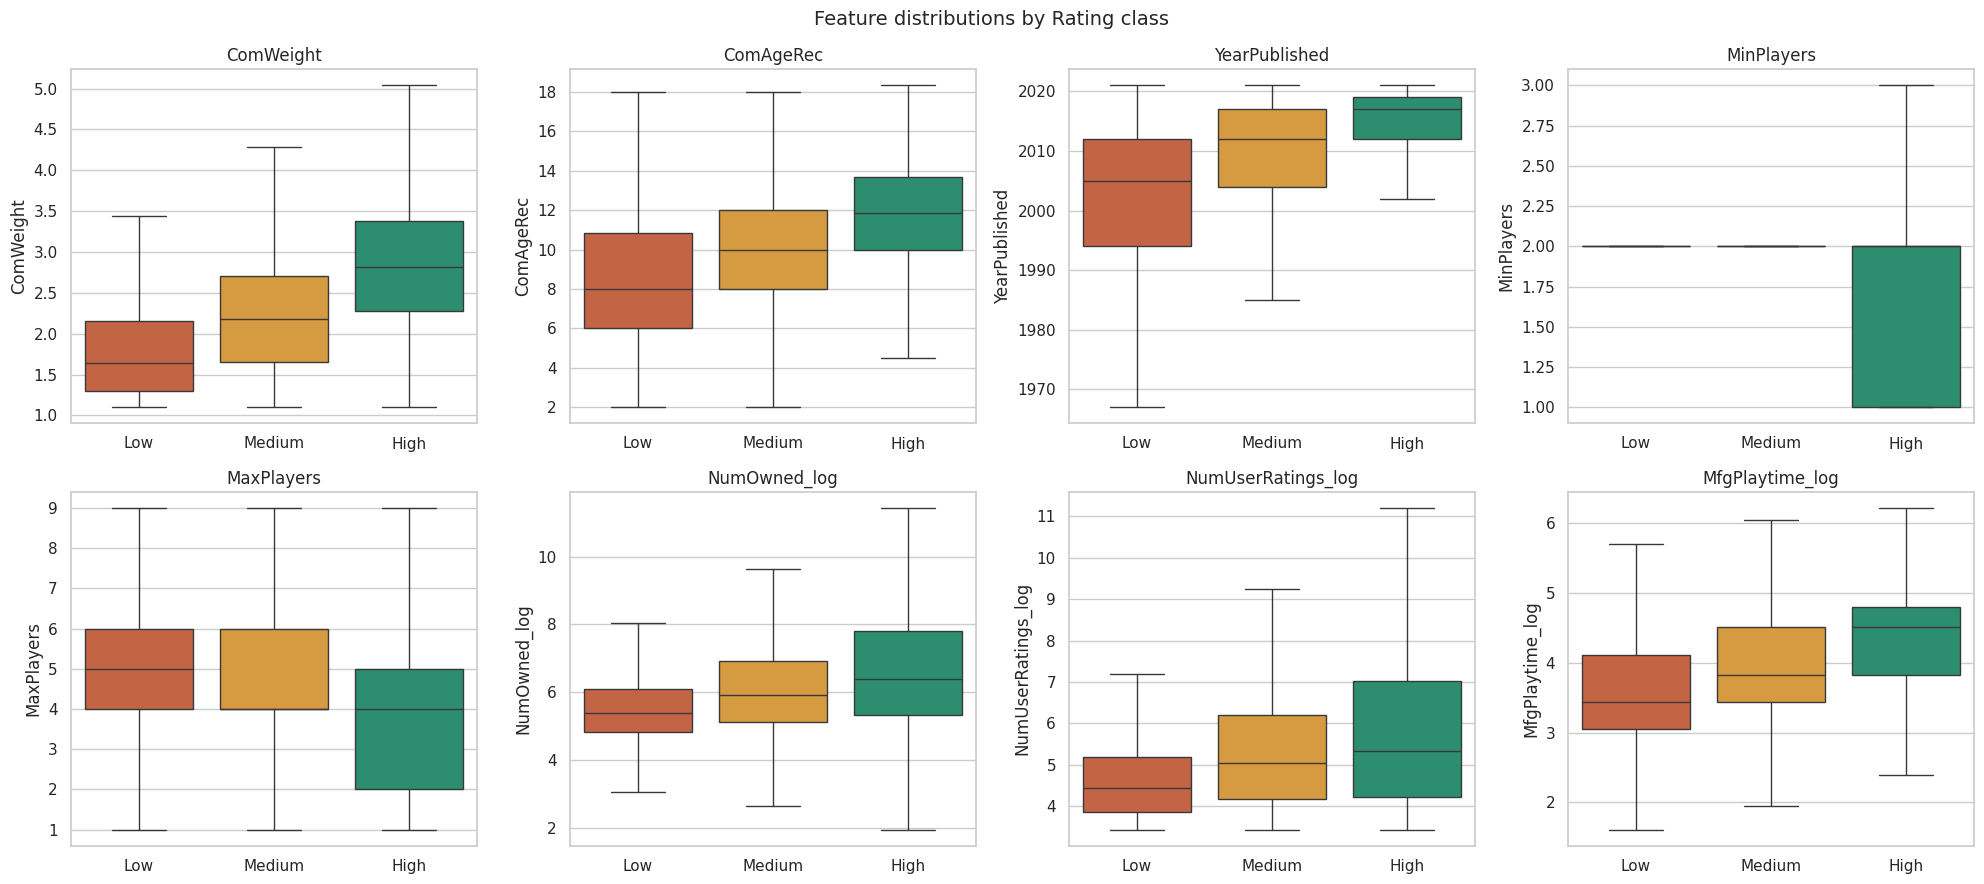

Rating                  Low   Medium     High
ComWeight              1.81     2.23     2.86
ComAgeRec              8.78     9.92    11.58
YearPublished       2001.17  2007.84  2013.68
MinPlayers             2.11     2.04     1.77
MaxPlayers             5.13     4.66     4.09
NumOwned_log           5.51     6.10     6.62
NumUserRatings_log     4.65     5.31     5.76
MfgPlaytime_log        3.61     3.89     4.47


In [ ]:
box_cols = ["ComWeight", "ComAgeRec", "YearPublished", "MinPlayers", "MaxPlayers",
            "NumOwned_log", "NumUserRatings_log", "MfgPlaytime_log"]
order = ["Low", "Medium", "High"]
palette = ["#D85A30", "#EF9F27", "#1D9E75"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), box_cols):
    sns.boxplot(data=data_clean, x="Rating", y=col, order=order,
                hue="Rating", hue_order=order, palette=palette,
                legend=False, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Feature distributions by Rating class", fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/features_by_rating.png', dpi=150)
plt.show()

print(data_clean.groupby("Rating")[box_cols].mean().reindex(order).round(2).T)

### Feature behaviour across Rating classes

All eight variables separate the three Rating classes monotonically, which is a
favourable starting point for the classification task in Module 3.

| Feature | Low | Medium | High | Direction |
|---|---|---|---|---|
| `ComWeight` | 1.81 | 2.23 | 2.86 | ↑ |
| `ComAgeRec` | 8.78 | 9.92 | 11.58 | ↑ |
| `YearPublished` | 2001 | 2008 | 2014 | ↑ |
| `MfgPlaytime_log` | 3.61 | 3.89 | 4.47 | ↑ |
| `NumOwned_log` | 5.51 | 6.10 | 6.62 | ↑ |
| `NumUserRatings_log` | 4.65 | 5.31 | 5.76 | ↑ |
| `MaxPlayers` | 5.13 | 4.66 | 4.09 | ↓ |
| `MinPlayers` | 2.11 | 2.04 | 1.77 | ↓ |

The strongest and most unexpected separator is `YearPublished`: highly rated
games are on average thirteen years more recent than poorly rated ones, and the
interquartile ranges barely overlap. Two mechanisms plausibly contribute. Board
game design has genuinely improved over the period covered, and BGG ratings are
submitted by an active community that plays and rates current titles far more
than historical ones, so older games accumulate a less enthusiastic and more
sparsely voted score. The variable is a strong predictor regardless of which
mechanism dominates, and it is included in the Module 3 feature set on this basis.

`ComWeight` shows the expected pattern — the community rewards complexity, with
mean difficulty rising from 1.81 to 2.86 across the classes — and `ComAgeRec`
and `MfgPlaytime_log` follow it, all three describing the same underlying
"hobbyist versus casual" axis.

The player-count variables move in the opposite direction: highly rated games
are designed for fewer players. The boxplots make the mechanism visible.
`MinPlayers` is effectively constant at 2 for the Low and Medium classes (median,
first and third quartile all coincide), while the High class extends down to 1,
i.e. it contains a substantially larger share of games supporting solo play.
Solo mode is a hallmark of modern hobbyist design, which ties this pattern back
to the `YearPublished` effect rather than making it an independent finding.

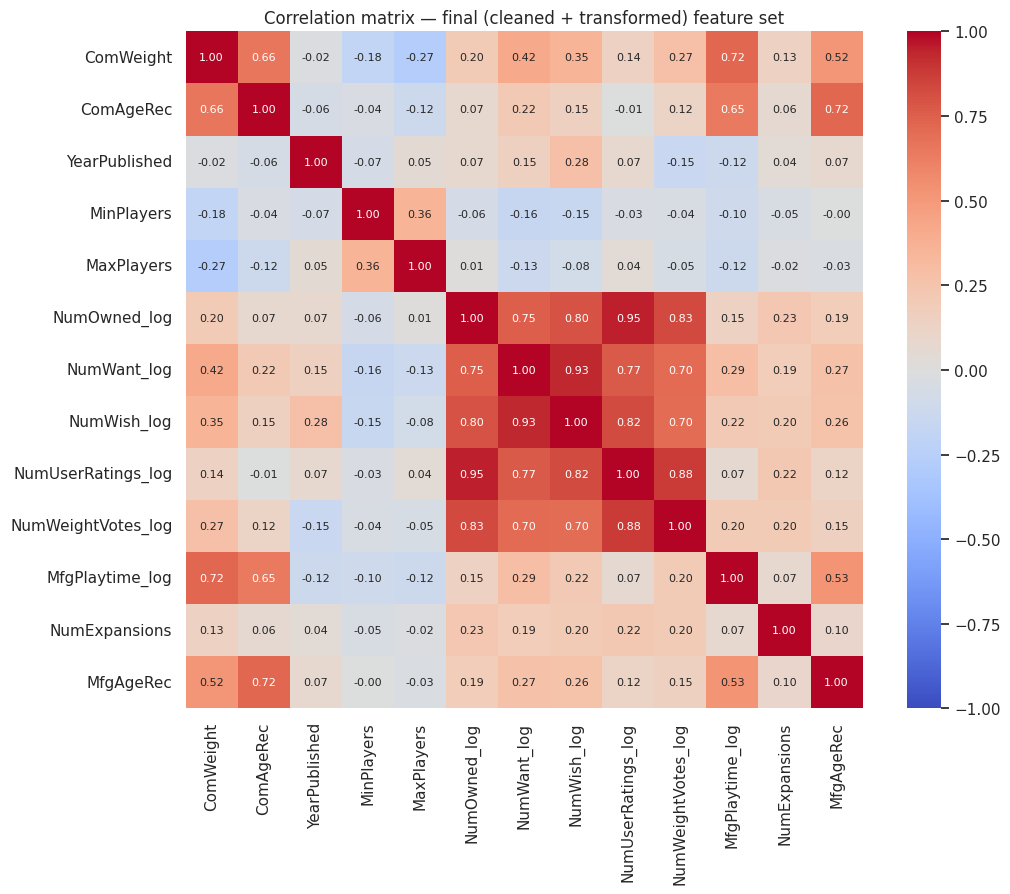

Pairs with |r| > 0.7:
NumOwned_log        NumUserRatings_log    0.951
NumWant_log         NumWish_log           0.930
NumUserRatings_log  NumWeightVotes_log    0.883
NumOwned_log        NumWeightVotes_log    0.832
NumWish_log         NumUserRatings_log    0.821
NumOwned_log        NumWish_log           0.804
NumWant_log         NumUserRatings_log    0.768
NumOwned_log        NumWant_log           0.751
ComAgeRec           MfgAgeRec             0.720
ComWeight           MfgPlaytime_log       0.719
NumWant_log         NumWeightVotes_log    0.704
NumWish_log         NumWeightVotes_log    0.700
dtype: float64


In [ ]:
final_cols = ["ComWeight", "ComAgeRec", "YearPublished", "MinPlayers", "MaxPlayers",
              "NumOwned_log", "NumWant_log", "NumWish_log", "NumUserRatings_log",
              "NumWeightVotes_log", "MfgPlaytime_log", "NumExpansions", "MfgAgeRec"]

corr_final = data_clean[final_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_final, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlation matrix — final (cleaned + transformed) feature set")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports/correlation_matrix_final.png', dpi=150)
plt.show()

high = (corr_final.where(np.triu(np.ones(corr_final.shape), k=1).astype(bool))
                  .stack().sort_values(key=abs, ascending=False))
print("Pairs with |r| > 0.7:")
print(high[abs(high) > 0.7].round(3))

### Correlations on the final feature set

Recomputing the correlation matrix after cleaning changes the picture materially
in one place. `ComWeight` and `MfgPlaytime_log` correlate at r = 0.72, against
r = 0.18 for the same pair on the raw data. The relationship was not weak — it
was obscured by the 780 records where `MfgPlaytime = 0` encoded "not specified",
which the log transform mapped onto a legitimate-looking value and which
therefore acted as noise spread across the whole complexity range. Treating the
sentinel as missing recovers a strong and substantively sensible relationship:
more complex games take longer to play. This is the clearest quantitative
evidence that the data preparation step was worth performing.

Twelve pairs exceed |r| = 0.7. They fall into three groups:

**The popularity block** (nine pairs, r = 0.70–0.95) covers `NumOwned_log`,
`NumWant_log`, `NumWish_log`, `NumUserRatings_log` and `NumWeightVotes_log`.
Two pairs within it are near-duplicates: `NumOwned_log`/`NumUserRatings_log`
at 0.95 and `NumWant_log`/`NumWish_log` at 0.93. The block behaves as a single
latent factor — community attention — measured five different ways, and at most
one or two of its members should enter any model as predictors.

**Community versus manufacturer pairs**: `ComAgeRec`/`MfgAgeRec` at 0.72. This
repeats the `GameWeight`/`ComWeight` pattern already identified on the raw data,
where the same attribute is recorded twice, once as declared by the publisher and
once as voted by the community. As before, the community version is retained:
it is the one the recommended-age analysis relies on. `MfgAgeRec` is excluded
from the modelling feature sets.

**`ComWeight`/`MfgPlaytime_log`** at 0.72, discussed above. Unlike the other two
groups this is a relationship between conceptually distinct attributes rather
than a redundancy, and it is exploited rather than eliminated: `MfgPlaytime_log`
becomes the independent variable of the simple regression task in Module 3.

`YearPublished`, `MinPlayers`, `MaxPlayers` and `NumExpansions` correlate weakly
with everything (|r| < 0.36 throughout). They carry largely independent
information and are retained in full.